In [1]:
!pip install -q gdown

In [2]:
import gdown

file_id = "15p1d523C0Zyocnug53HrLWtAZ8XV_kTU"
output = "/kaggle/working/data.zip"

gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=15p1d523C0Zyocnug53HrLWtAZ8XV_kTU
From (redirected): https://drive.google.com/uc?id=15p1d523C0Zyocnug53HrLWtAZ8XV_kTU&confirm=t&uuid=9e9d0edf-2651-4911-8ddf-b06f24325b50
To: /kaggle/working/data.zip
100%|██████████| 2.79G/2.79G [00:26<00:00, 106MB/s] 


'/kaggle/working/data.zip'

In [3]:
!unzip -q /kaggle/working/data.zip -d /kaggle/working/data

In [4]:
import gdown

file_id = "12dNsuo452p7BJN9SjItWJCJtZDCOldHe"
output = "/kaggle/working/extra.zip"

gdown.download(id=file_id, output=output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=12dNsuo452p7BJN9SjItWJCJtZDCOldHe
From (redirected): https://drive.google.com/uc?id=12dNsuo452p7BJN9SjItWJCJtZDCOldHe&confirm=t&uuid=59a29638-1aff-4017-bf73-e3511731c069
To: /kaggle/working/extra.zip
100%|██████████| 1.16G/1.16G [00:10<00:00, 112MB/s] 


'/kaggle/working/extra.zip'

In [5]:
!unzip -o /kaggle/working/extra.zip \
-d /kaggle/working/data/Offroad_Segmentation_Training_Dataset

Archive:  /kaggle/working/extra.zip
   creating: /kaggle/working/data/Offroad_Segmentation_Training_Dataset/test/
   creating: /kaggle/working/data/Offroad_Segmentation_Training_Dataset/test/Color_Images/
  inflating: /kaggle/working/data/Offroad_Segmentation_Training_Dataset/test/Color_Images/0000060.png  
  inflating: /kaggle/working/data/Offroad_Segmentation_Training_Dataset/test/Color_Images/0000061.png  
  inflating: /kaggle/working/data/Offroad_Segmentation_Training_Dataset/test/Color_Images/0000062.png  
  inflating: /kaggle/working/data/Offroad_Segmentation_Training_Dataset/test/Color_Images/0000063.png  
  inflating: /kaggle/working/data/Offroad_Segmentation_Training_Dataset/test/Color_Images/0000064.png  
  inflating: /kaggle/working/data/Offroad_Segmentation_Training_Dataset/test/Color_Images/0000065.png  
  inflating: /kaggle/working/data/Offroad_Segmentation_Training_Dataset/test/Color_Images/0000066.png  
  inflating: /kaggle/working/data/Offroad_Segmentation_Training_Dat

In [6]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.5 MB/s eta 0:00:00


In [7]:
!pip install -U wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 95.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: wandb
    Found existing installation: wandb 0.22.2
    Uninstalling wandb-0.22.2:
      Successfully uninstalled wandb-0.22.2


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from collections import Counter
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import wandb
import json
from datetime import datetime
import shutil
import time

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.8.0+cu126
CUDA available: True
Device: cuda


In [9]:
class Config:
    # Project info
    PROJECT_NAME = "duality-offroad-segmentation"
    RUN_NAME = f"unet-resnet34-multi-gpu-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
    
    # Kaggle paths
    DATA_ROOT = "/kaggle/input/offroad-segmentation-dataset"
    DATASET_ROOT = "/kaggle/working/data/Offroad_Segmentation_Training_Dataset"
    CHECKPOINT_DIR = f"/kaggle/working/checkpoints/{RUN_NAME}"
    OUTPUT_DIR = f"/kaggle/working/outputs/{RUN_NAME}"
    
    # Dataset paths
    TRAIN_IMG_DIR = f"{DATASET_ROOT}/train/Color_Images"
    TRAIN_MASK_DIR = f"{DATASET_ROOT}/train/Segmentation"
    VAL_IMG_DIR = f"{DATASET_ROOT}/val/Color_Images"
    VAL_MASK_DIR = f"{DATASET_ROOT}/val/Segmentation"
    TEST_IMG_DIR = f"/kaggle/working/data/Offroad_Segmentation_Training_Dataset/test"
    
    # Model
    ENCODER = "resnet34"
    ENCODER_WEIGHTS = "imagenet"
    NUM_CLASSES = 10
    ACTIVATION = None
    
    # Training - Multi-GPU optimized
    USE_MULTI_GPU = True
    USE_AMP = True
    BATCH_SIZE = 16
    NUM_EPOCHS = 100
    LEARNING_RATE = 5e-4
    WEIGHT_DECAY = 1e-4
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    NUM_WORKERS = 4
    
    # Image
    IMG_HEIGHT = 544
    IMG_WIDTH = 960
    
    # Class mapping
    CLASS_MAPPING = {
        100: 0,    # Trees
        200: 1,    # Lush Bushes
        300: 2,    # Dry Grass
        500: 3,    # Dry Bushes
        550: 4,    # Ground Clutter
        600: 5,    # Flowers
        700: 6,    # Logs
        800: 7,    # Rocks
        7100: 8,   # Landscape
        10000: 9,  # Sky
    }
    
    CLASS_NAMES = ["Trees", "Lush Bushes", "Dry Grass", "Dry Bushes",
                   "Ground Clutter", "Flowers", "Logs", "Rocks",
                   "Landscape", "Sky"]
    
    # Early stopping
    EARLY_STOPPING_PATIENCE = 20
    MIN_DELTA = 0.001
    
    # Checkpointing
    SAVE_FREQUENCY = 5           # Save checkpoint every N epochs
    KEEP_LAST_N_CHECKPOINTS = 3  # Keep last 3 .pth files
    BACKUP_FREQUENCY = 5         # Create full ZIP every N epochs
    
    # Resume training
    RESUME_FROM_CHECKPOINT = None
    
    # WandB
    USE_WANDB = True

# Create directories
Path(Config.CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)
Path(Config.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("✓ Configuration loaded")
print(f"✓ Run name: {Config.RUN_NAME}")
print(f"✓ Checkpoints: {Config.CHECKPOINT_DIR}")
print(f"✓ ZIP backup every {Config.BACKUP_FREQUENCY} epochs")
print(f"✓ Keeps last 2 full ZIPs + last 2 quick ZIPs")
print("=" * 70)

✓ Configuration loaded
✓ Run name: unet-resnet34-multi-gpu-20260131-070945
✓ Checkpoints: /kaggle/working/checkpoints/unet-resnet34-multi-gpu-20260131-070945
✓ ZIP backup every 5 epochs
✓ Keeps last 2 full ZIPs + last 2 quick ZIPs


In [10]:
# CELL 4: WandB Initialization
if Config.USE_WANDB:
    try:
        # Go to Kaggle notebook settings → Add-ons → Secrets
        # Add a secret with name 'WANDB_API_KEY' and your WandB API key as value
        from kaggle_secrets import UserSecretsClient
        user_secrets = UserSecretsClient()
        wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")
        
        import os
        os.environ['WANDB_API_KEY'] = wandb_api_key
        wandb.login(key=wandb_api_key)
        
        wandb.init(
            project=Config.PROJECT_NAME,
            name=Config.RUN_NAME,
            config={
                "encoder": Config.ENCODER,
                "batch_size": Config.BATCH_SIZE,
                "learning_rate": Config.LEARNING_RATE,
                "epochs": Config.NUM_EPOCHS,
                "image_size": f"{Config.IMG_HEIGHT}x{Config.IMG_WIDTH}",
                "multi_gpu": Config.USE_MULTI_GPU,
                "mixed_precision": Config.USE_AMP,
                "num_gpus": torch.cuda.device_count(),
            }
        )
        print("✓ WandB initialized successfully")
        
    except Exception as e:
        print(f"⚠ WandB initialization failed: {e}")
        print("Continuing without WandB logging...")
        Config.USE_WANDB = False
else:
    print("WandB disabled")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: abhinav0231 (abhinav0231-krmangalam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ WandB initialized successfully


In [11]:
def get_training_augmentation():
    """Comprehensive on-the-fly augmentations"""
    return A.Compose([
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.ShiftScaleRotate(
            shift_limit=0.1,
            scale_limit=0.2,
            rotate_limit=30,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.5,
        ),
        A.RandomResizedCrop(
            size=(Config.IMG_HEIGHT, Config.IMG_WIDTH),
            scale=(0.7, 1.0),
            p=0.5,
        ),
        A.RandomBrightnessContrast(
            brightness_limit=0.3,
            contrast_limit=0.3,
            p=0.7,
        ),
        A.RandomGamma(gamma_limit=(80, 120), p=0.5),
        A.HueSaturationValue(
            hue_shift_limit=20,
            sat_shift_limit=30,
            val_shift_limit=20,
            p=0.5,
        ),
        A.OneOf([
            A.RandomSunFlare(p=1),
            A.RandomShadow(p=1),
            A.RandomFog(p=1),
        ], p=0.3),
        A.OneOf([
            A.MotionBlur(blur_limit=5, p=1),
            A.MedianBlur(blur_limit=5, p=1),
            A.GaussianBlur(blur_limit=5, p=1),
        ], p=0.3),
        A.OneOf([
            A.GaussNoise(p=1),
            A.ISONoise(p=1),
        ], p=0.3),
        A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
        A.CoarseDropout(p=0.3),
        
        # Always resize to target size at the end
        A.Resize(Config.IMG_HEIGHT, Config.IMG_WIDTH),
        
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

def get_validation_augmentation():
    """Minimal augmentation for validation"""
    return A.Compose([
        A.Resize(Config.IMG_HEIGHT, Config.IMG_WIDTH),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

print("Augmentation functions defined")

Augmentation functions defined


In [12]:
class DesertSegmentationDataset(Dataset):
    """Dataset for Duality AI Challenge"""
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        
        # Get image paths
        self.image_paths = sorted(list(self.image_dir.glob("*.png")))
        if len(self.image_paths) == 0:
            self.image_paths = sorted(list(self.image_dir.glob("*.jpg")))
        
        print(f"Found {len(self.image_paths)} images in {image_dir}")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load image
        img_path = self.image_paths[idx]
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask_path = self.mask_dir / img_path.name
        mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
        
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {mask_path}")
        
        # Remap mask
        remapped_mask = np.zeros_like(mask, dtype=np.int64)
        for old_id, new_id in Config.CLASS_MAPPING.items():
            remapped_mask[mask == old_id] = new_id
        
        # Apply augmentations
        if self.transform:
            augmented = self.transform(image=image, mask=remapped_mask)
            image = augmented['image']
            remapped_mask = augmented['mask']
        
        return image, remapped_mask.long()

print("Dataset class defined")

Dataset class defined


In [13]:
from collections import Counter

def check_class_distribution(mask_dir, dataset_name="Dataset"):
    """Check pixel-wise class distribution"""
    class_counts = Counter()
    image_class_presence = {i: 0 for i in range(Config.NUM_CLASSES)}
    
    mask_paths = list(Path(mask_dir).glob("*.png"))
    if len(mask_paths) == 0:
        mask_paths = list(Path(mask_dir).glob("*.jpg"))
    
    print(f"\n{dataset_name} - Total images: {len(mask_paths)}")
    
    for mask_path in tqdm(mask_paths, desc=f"Analyzing {dataset_name}"):
        mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
        
        # Remap mask
        remapped_mask = np.zeros_like(mask, dtype=np.int64)
        for old_id, new_id in Config.CLASS_MAPPING.items():
            remapped_mask[mask == old_id] = new_id
        
        # Count pixels
        unique, counts = np.unique(remapped_mask, return_counts=True)
        for cls, count in zip(unique, counts):
            class_counts[cls] += count
            image_class_presence[cls] += 1
    
    # Print results
    total_pixels = sum(class_counts.values())
    print(f"\n{dataset_name} Class Distribution:")
    print("-" * 70)
    for i, class_name in enumerate(Config.CLASS_NAMES):
        pixel_count = class_counts.get(i, 0)
        pixel_pct = (pixel_count / total_pixels * 100) if total_pixels > 0 else 0
        img_presence = image_class_presence.get(i, 0)
        img_pct = (img_presence / len(mask_paths) * 100) if len(mask_paths) > 0 else 0
        print(f"{class_name:15s}: {pixel_count:12,d} pixels ({pixel_pct:5.2f}%) | "
              f"Present in {img_presence:4d}/{len(mask_paths)} images ({img_pct:5.2f}%)")
    
    return class_counts, image_class_presence

# Check distributions
print("=" * 70)
print("ANALYZING CLASS DISTRIBUTIONS")
print("=" * 70)

train_dist, train_presence = check_class_distribution(Config.TRAIN_MASK_DIR, "TRAIN")
val_dist, val_presence = check_class_distribution(Config.VAL_MASK_DIR, "VAL")

total_pixels = sum(train_dist.values())

# Manual weights with strategic boosting
class_weights = torch.tensor([
    1.1,   # Trees (good at 0.69)
    0.9,   # Lush Bushes (good at 0.67)
    0.6,   # Dry Grass (good at 0.67, most common)
    3.0,   # Dry Bushes ← BOOSTED from 1.59 to 3.0
    1.2,   # Ground Clutter (improved to 0.42)
    2.5,   # Flowers ← BOOSTED from 1.20 to 2.5
    1.8,   # Logs (improved to 0.31)
    1.5,   # Rocks (improved to 0.50)
    0.5,   # Landscape (good at 0.66)
    0.4,   # Sky (excellent at 0.94)
], dtype=torch.float32)

# Normalize
class_weights = class_weights / class_weights.sum() * Config.NUM_CLASSES

print(f"\n{'='*70}")
print("OPTIMIZED CLASS WEIGHTS (BOOSTED DRY BUSHES & FLOWERS)")
print(f"{'='*70}")
for i, (name, weight) in enumerate(zip(Config.CLASS_NAMES, class_weights)):
    pixel_pct = (train_dist.get(i, 0) / total_pixels * 100)
    marker = "🔥" if weight > 2.0 else "✓"
    print(f"{marker} {name:15s}: {weight:.4f} (pixel%: {pixel_pct:5.2f}%)")

print(f"\n✓ Dry Bushes weight: {class_weights[3]:.2f} (was 1.59, now 3.0)")
print(f"✓ Flowers weight: {class_weights[5]:.2f} (was 1.20, now 2.5)")
print("=" * 70)

ANALYZING CLASS DISTRIBUTIONS

TRAIN - Total images: 2857


Analyzing TRAIN: 100%|██████████| 2857/2857 [00:26<00:00, 108.20it/s]



TRAIN Class Distribution:
----------------------------------------------------------------------
Trees          :   52,331,525 pixels ( 3.53%) | Present in 2247/2857 images (78.65%)
Lush Bushes    :   87,892,776 pixels ( 5.93%) | Present in 2806/2857 images (98.21%)
Dry Grass      :  279,430,843 pixels (18.87%) | Present in 2826/2857 images (98.91%)
Dry Bushes     :   16,268,713 pixels ( 1.10%) | Present in  914/2857 images (31.99%)
Ground Clutter :   65,082,995 pixels ( 4.39%) | Present in 2855/2857 images (99.93%)
Flowers        :   41,585,811 pixels ( 2.81%) | Present in 1010/2857 images (35.35%)
Logs           :    1,153,995 pixels ( 0.08%) | Present in 1685/2857 images (58.98%)
Rocks          :   17,743,187 pixels ( 1.20%) | Present in 2823/2857 images (98.81%)
Landscape      :  362,120,221 pixels (24.45%) | Present in 2855/2857 images (99.93%)
Sky            :  557,458,734 pixels (37.64%) | Present in 2587/2857 images (90.55%)

VAL - Total images: 317


Analyzing VAL: 100%|██████████| 317/317 [00:02<00:00, 107.88it/s]



VAL Class Distribution:
----------------------------------------------------------------------
Trees          :    6,685,175 pixels ( 4.07%) | Present in  246/317 images (77.60%)
Lush Bushes    :    9,887,005 pixels ( 6.02%) | Present in  311/317 images (98.11%)
Dry Grass      :   31,778,064 pixels (19.34%) | Present in  312/317 images (98.42%)
Dry Bushes     :    1,806,117 pixels ( 1.10%) | Present in  100/317 images (31.55%)
Ground Clutter :    6,966,231 pixels ( 4.24%) | Present in  315/317 images (99.37%)
Flowers        :    4,001,940 pixels ( 2.44%) | Present in  103/317 images (32.49%)
Logs           :      109,285 pixels ( 0.07%) | Present in  188/317 images (59.31%)
Rocks          :    1,995,285 pixels ( 1.21%) | Present in  312/317 images (98.42%)
Landscape      :   39,059,907 pixels (23.77%) | Present in  316/317 images (99.68%)
Sky            :   62,043,791 pixels (37.75%) | Present in  288/317 images (90.85%)

OPTIMIZED CLASS WEIGHTS (BOOSTED DRY BUSHES & FLOWERS)
✓ Trees 

In [14]:
# Create weighted sampler to oversample images with Dry Bushes & Flowers
from torch.utils.data import WeightedRandomSampler

def create_weighted_sampler(mask_dir):
    """Give 3x weight to images containing Dry Bushes or Flowers"""
    mask_paths = sorted(list(Path(mask_dir).glob("*.png")))
    if len(mask_paths) == 0:
        mask_paths = sorted(list(Path(mask_dir).glob("*.jpg")))
    
    sample_weights = []
    dry_bushes_count = 0
    flowers_count = 0
    
    print("Analyzing images for weighted sampling...")
    for mask_path in tqdm(mask_paths):
        mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
        
        # Check if contains target classes
        has_dry_bushes = (mask == 500).any()  # Dry Bushes
        has_flowers = (mask == 600).any()      # Flowers
        
        if has_dry_bushes or has_flowers:
            sample_weights.append(3.0)  # 3x weight
            if has_dry_bushes:
                dry_bushes_count += 1
            if has_flowers:
                flowers_count += 1
        else:
            sample_weights.append(1.0)  # Normal weight
    
    print(f"\n📊 Weighted Sampling Stats:")
    print(f"   Images with Dry Bushes: {dry_bushes_count}/{len(mask_paths)} ({dry_bushes_count/len(mask_paths)*100:.1f}%)")
    print(f"   Images with Flowers: {flowers_count}/{len(mask_paths)} ({flowers_count/len(mask_paths)*100:.1f}%)")
    print(f"   Boosted images will appear 3x more often during training")
    
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )

# Create sampler
train_sampler = create_weighted_sampler(Config.TRAIN_MASK_DIR)
print("✓ Weighted sampler created\n")

Analyzing images for weighted sampling...


100%|██████████| 2857/2857 [00:11<00:00, 252.92it/s]


📊 Weighted Sampling Stats:
   Images with Dry Bushes: 914/2857 (32.0%)
   Images with Flowers: 1010/2857 (35.4%)
   Boosted images will appear 3x more often during training
✓ Weighted sampler created



In [15]:
# Create datasets
train_dataset = DesertSegmentationDataset(
    Config.TRAIN_IMG_DIR,
    Config.TRAIN_MASK_DIR,
    transform=get_training_augmentation()
)

val_dataset = DesertSegmentationDataset(
    Config.VAL_IMG_DIR,
    Config.VAL_MASK_DIR,
    transform=get_validation_augmentation()
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    sampler=train_sampler,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True,
)

print("=" * 70)
print("Dataloaders created with WEIGHTED SAMPLING")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print("=" * 70)

Found 2857 images in /kaggle/working/data/Offroad_Segmentation_Training_Dataset/train/Color_Images
Found 317 images in /kaggle/working/data/Offroad_Segmentation_Training_Dataset/val/Color_Images
Dataloaders created with WEIGHTED SAMPLING
Train batches: 179
Val batches: 20


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [16]:
def calculate_iou(pred, target, num_classes=Config.NUM_CLASSES):
    """Calculate IoU for segmentation"""
    ious = []
    pred = pred.view(-1).cpu().numpy()
    target = target.view(-1).cpu().numpy()
    
    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds & target_inds).sum()
        union = (pred_inds | target_inds).sum()
        
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)
    
    # Mean IoU (ignoring NaN values)
    valid_ious = [iou for iou in ious if not np.isnan(iou)]
    mean_iou = np.mean(valid_ious) if valid_ious else 0.0
    
    return mean_iou, np.array(ious)

def calculate_pixel_accuracy(pred, target):
    """Calculate pixel-wise accuracy"""
    correct = (pred == target).sum().item()
    total = target.numel()
    return correct / total

print("Metrics functions defined")

Metrics functions defined


In [17]:
class CombinedLoss(nn.Module):
    """Combination of Dice Loss and CrossEntropy with class weights"""
    def __init__(self, class_weights=None, dice_weight=0.5, ce_weight=0.5):
        super().__init__()
        self.dice_weight = dice_weight
        self.ce_weight = ce_weight
        self.class_weights = class_weights
        
        # CrossEntropy with class weights
        if class_weights is not None:
            self.ce = nn.CrossEntropyLoss(weight=class_weights)
        else:
            self.ce = nn.CrossEntropyLoss()
    
    def dice_loss(self, pred, target, smooth=1e-6):
        """Soft Dice Loss"""
        pred = torch.softmax(pred, dim=1)
        target_one_hot = torch.zeros_like(pred)
        target_one_hot.scatter_(1, target.unsqueeze(1), 1)
        
        intersection = (pred * target_one_hot).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))
        
        dice_score = (2. * intersection + smooth) / (union + smooth)
        return 1 - dice_score.mean()
    
    def forward(self, pred, target):
        dice = self.dice_loss(pred, target)
        ce = self.ce(pred, target)
        return self.dice_weight * dice + self.ce_weight * ce

print("Loss function defined")

Loss function defined


In [18]:
import zipfile
from datetime import datetime
from pathlib import Path

def create_backup_zip(epoch, include_all=False):
    """Create a downloadable ZIP backup of checkpoints and outputs"""
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    if include_all:
        # Full backup - everything
        zip_filename = f"/kaggle/working/full_backup_{Config.RUN_NAME}_ep{epoch+1}_{timestamp}.zip"
        print(f"\n{'='*70}")
        print("Creating FULL BACKUP ZIP...")
        print(f"{'='*70}")
    else:
        # Quick backup - just best model and latest checkpoint
        zip_filename = f"/kaggle/working/quick_backup_{Config.RUN_NAME}_ep{epoch+1}.zip"
        print(f"\nCreating quick backup ZIP...")
    
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Always include best model
        best_model_path = Path(Config.CHECKPOINT_DIR) / "best_model.pth"
        if best_model_path.exists():
            zipf.write(best_model_path, arcname=f"checkpoints/best_model.pth")
            print(f"  ✓ Added: best_model.pth")
        
        if include_all:
            # Add all checkpoints
            for ckpt_file in Path(Config.CHECKPOINT_DIR).glob("checkpoint_epoch_*.pth"):
                zipf.write(ckpt_file, arcname=f"checkpoints/{ckpt_file.name}")
                print(f"  ✓ Added: {ckpt_file.name}")
            
            # Add training history JSON if exists
            history_path = Path(Config.OUTPUT_DIR) / "training_history.json"
            if history_path.exists():
                zipf.write(history_path, arcname="training_history.json")
                print(f"  ✓ Added: training_history.json")
            
            # Add training curves image if exists
            for img_file in Path(Config.OUTPUT_DIR).glob("*.png"):
                zipf.write(img_file, arcname=f"outputs/{img_file.name}")
                print(f"  ✓ Added: {img_file.name}")
            
            # Add any other output files
            for output_file in Path(Config.OUTPUT_DIR).glob("*.txt"):
                zipf.write(output_file, arcname=f"outputs/{output_file.name}")
                print(f"  ✓ Added: {output_file.name}")
        else:
            # Quick backup - just latest checkpoint
            latest_ckpt = Path(Config.CHECKPOINT_DIR) / f"checkpoint_epoch_{epoch+1}.pth"
            if latest_ckpt.exists():
                zipf.write(latest_ckpt, arcname=f"checkpoints/{latest_ckpt.name}")
                print(f"  ✓ Added: {latest_ckpt.name}")
    
    zip_size_mb = Path(zip_filename).stat().st_size / (1024 * 1024)
    print(f"{'='*70}")
    print(f"✓ ZIP created: {Path(zip_filename).name}")
    print(f"✓ Size: {zip_size_mb:.2f} MB")
    print(f"✓ Location: /kaggle/working/")
    print(f"{'='*70}\n")
    
    return zip_filename


def save_checkpoint(epoch, model, optimizer, scheduler, scaler, metrics, is_best):
    """Save checkpoint locally AND create ZIP backup with auto-cleanup"""
    # Extract model if DataParallel
    model_state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model_state,
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'metrics': metrics,
        'config': {
            'encoder': Config.ENCODER,
            'num_classes': Config.NUM_CLASSES,
            'img_size': (Config.IMG_HEIGHT, Config.IMG_WIDTH),
            'run_name': Config.RUN_NAME,
        }
    }
    
    # Save local checkpoint
    checkpoint_path = Path(Config.CHECKPOINT_DIR) / f"checkpoint_epoch_{epoch+1}.pth"
    torch.save(checkpoint, checkpoint_path)
    print(f"✓ Saved: {checkpoint_path.name}")
    
    # Save best model
    if is_best:
        best_path = Path(Config.CHECKPOINT_DIR) / "best_model.pth"
        torch.save(checkpoint, best_path)
        print(f"✓ BEST MODEL! Val IoU: {metrics.get('val_iou', 0):.4f}")
        
        # Create quick ZIP backup when best model is saved
        create_backup_zip(epoch, include_all=False)
        
        # Clean up old quick backups (keep only last 2)
        quick_backups = sorted(Path("/kaggle/working").glob("quick_backup_*.zip"))
        if len(quick_backups) > 2:
            for old_zip in quick_backups[:-2]:
                old_size_mb = old_zip.stat().st_size / (1024 * 1024)
                old_zip.unlink()
                print(f"  🗑️  Deleted old quick backup: {old_zip.name} ({old_size_mb:.1f} MB freed)")
    
    # Create full backup every N epochs
    if (epoch + 1) % Config.BACKUP_FREQUENCY == 0:
        create_backup_zip(epoch, include_all=True)
        
        # Clean up old full backups (keep only last 2)
        full_backups = sorted(Path("/kaggle/working").glob("full_backup_*.zip"))
        if len(full_backups) > 2:
            for old_zip in full_backups[:-2]:
                old_size_mb = old_zip.stat().st_size / (1024 * 1024)
                old_zip.unlink()
                print(f"  🗑️  Deleted old full backup: {old_zip.name} ({old_size_mb:.1f} MB freed)")
    
    # Keep only last N checkpoints locally (save space)
    checkpoints = sorted(Path(Config.CHECKPOINT_DIR).glob("checkpoint_epoch_*.pth"))
    if len(checkpoints) > Config.KEEP_LAST_N_CHECKPOINTS:
        for old_checkpoint in checkpoints[:-Config.KEEP_LAST_N_CHECKPOINTS]:
            old_checkpoint.unlink()


def load_checkpoint(checkpoint_path, model, optimizer, scheduler, scaler):
    """Load checkpoint"""
    checkpoint = torch.load(checkpoint_path)
    
    # Load into module if DataParallel
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint['model_state_dict'])
    
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    
    return checkpoint['epoch'], checkpoint['metrics']


print("✓ Checkpoint functions defined (with ZIP backup + auto-cleanup)")

✓ Checkpoint functions defined (with ZIP backup + auto-cleanup)


In [19]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, scaler, device, epoch):
    """Train for one epoch with mixed precision"""
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    running_acc = 0.0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch} Train")
    for batch_idx, (images, masks) in enumerate(pbar):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        # Mixed precision forward
        with torch.cuda.amp.autocast(enabled=Config.USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, masks)
        
        # Mixed precision backward
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Step scheduler every batch for OneCycleLR
        scheduler.step()
        
        # Metrics (outside autocast)
        with torch.no_grad():
            preds = torch.argmax(outputs, dim=1)
            batch_iou, _ = calculate_iou(preds, masks)
            batch_acc = calculate_pixel_accuracy(preds, masks)
        
        running_loss += loss.item()
        running_iou += batch_iou
        running_acc += batch_acc
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'iou': f'{batch_iou:.4f}',
            'acc': f'{batch_acc:.4f}',
            'lr': f'{optimizer.param_groups[0]["lr"]:.2e}'
        })
        
        # Log to WandB periodically
        if Config.USE_WANDB and batch_idx % 50 == 0:
            wandb.log({
                'batch_train_loss': loss.item(),
                'batch_train_iou': batch_iou,
                'batch_train_acc': batch_acc,
                'learning_rate': optimizer.param_groups[0]['lr'],
            })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    epoch_acc = running_acc / len(dataloader)
    
    return epoch_loss, epoch_iou, epoch_acc

def validate_epoch(model, dataloader, criterion, device, epoch):
    """Validation with mixed precision"""
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    running_acc = 0.0
    class_iou_sum = np.zeros(Config.NUM_CLASSES)
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc=f"Epoch {epoch} Val")
        for images, masks in pbar:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            
            # Mixed precision inference
            with torch.cuda.amp.autocast(enabled=Config.USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, masks)
            
            preds = torch.argmax(outputs, dim=1)
            batch_iou, class_ious = calculate_iou(preds, masks)
            batch_acc = calculate_pixel_accuracy(preds, masks)
            
            running_loss += loss.item()
            running_iou += batch_iou
            running_acc += batch_acc
            
            # Handle NaN in class IoUs
            class_ious = np.nan_to_num(class_ious, nan=0.0)
            class_iou_sum += class_ious
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'iou': f'{batch_iou:.4f}',
                'acc': f'{batch_acc:.4f}'
            })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    epoch_acc = running_acc / len(dataloader)
    class_ious = class_iou_sum / len(dataloader)
    
    return epoch_loss, epoch_iou, epoch_acc, class_ious

print("Training functions defined")

Training functions defined


In [20]:
class EarlyStopping:
    """Early stopping with patience"""
    def __init__(self, patience=20, min_delta=0.001):  # Increased patience
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
    
    def __call__(self, val_metric):
        score = val_metric
        
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0
        
        return self.early_stop

early_stopping = EarlyStopping(
    patience=20,  # Increased from 15
    min_delta=0.001
)

print("Early stopping initialized (patience=20)")

Early stopping initialized (patience=20)


In [21]:
print("=" * 70)
print("INITIALIZING MODEL AND TRAINING COMPONENTS")
print("=" * 70)

# Create model
model = smp.Unet(
    encoder_name=Config.ENCODER,
    encoder_weights=Config.ENCODER_WEIGHTS,
    in_channels=3,
    classes=Config.NUM_CLASSES,
    activation=Config.ACTIVATION,
)

print(f"Model created: {Config.ENCODER}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Multi-GPU wrapper
if Config.USE_MULTI_GPU and torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs with DataParallel")
    model = nn.DataParallel(model)
else:
    print("Using single GPU")

model = model.to(Config.DEVICE)

# Loss with HIGHER DICE WEIGHT for better IoU
criterion = CombinedLoss(
    class_weights=class_weights.to(Config.DEVICE),
    dice_weight=0.75,  # Increased from 0.7 → 0.75
    ce_weight=0.25     # Decreased from 0.3 → 0.25
)
print("Loss: 0.75*Dice + 0.25*CrossEntropy (boosted Dry Bushes & Flowers)")

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=Config.LEARNING_RATE,
    weight_decay=Config.WEIGHT_DECAY,
    betas=(0.9, 0.999),
)
print(f"Optimizer: AdamW (lr={Config.LEARNING_RATE}, wd={Config.WEIGHT_DECAY})")

# Scheduler
steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=Config.LEARNING_RATE,
    epochs=Config.NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.2,
    anneal_strategy='cos',
    div_factor=10.0,
    final_div_factor=1e3,
)
print(f"Scheduler: OneCycleLR (peak at epoch ~{int(Config.NUM_EPOCHS*0.2)})")

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler(enabled=Config.USE_AMP)
print(f"Mixed Precision: {'Enabled' if Config.USE_AMP else 'Disabled'}")

# Training state
start_epoch = 0
best_iou = 0.0
history = {
    'train_loss': [],
    'train_iou': [],
    'train_acc': [],
    'val_loss': [],
    'val_iou': [],
    'val_acc': [],
    'class_ious': [],
}

print("=" * 70)
print("OPTIMIZATIONS FOR DRY BUSHES & FLOWERS:")
print("=" * 70)
print("✓ Class weights: Dry Bushes 3.0, Flowers 2.5")
print("✓ Weighted sampling: 3x oversampling of target classes")
print("✓ Dice weight: 0.75 (higher IoU focus)")
print("✓ Drive backup: Every 5 epochs + best model")
print("=" * 70)

INITIALIZING MODEL AND TRAINING COMPONENTS


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model created: resnet34
Total parameters: 24,437,674
Using 2 GPUs with DataParallel
Loss: 0.75*Dice + 0.25*CrossEntropy (boosted Dry Bushes & Flowers)
Optimizer: AdamW (lr=0.0005, wd=0.0001)
Scheduler: OneCycleLR (peak at epoch ~20)
Mixed Precision: Enabled
OPTIMIZATIONS FOR DRY BUSHES & FLOWERS:
✓ Class weights: Dry Bushes 3.0, Flowers 2.5
✓ Weighted sampling: 3x oversampling of target classes
✓ Dice weight: 0.75 (higher IoU focus)
✓ Drive backup: Every 5 epochs + best model


/tmp/ipykernel_55/2671404664.py:58: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=Config.USE_AMP)


In [22]:
# Run all cells in order, then this training loop:
print("=" * 70)
print("STARTING TRAINING WITH AUTO-CLEANUP")
print("=" * 70)

for epoch in range(start_epoch, Config.NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{Config.NUM_EPOCHS}")
    print("-" * 70)
    
    # Train
    train_loss, train_iou, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, scaler, Config.DEVICE, epoch+1
    )
    
    # Validate
    val_loss, val_iou, val_acc, class_ious = validate_epoch(
        model, val_loader, criterion, Config.DEVICE, epoch+1
    )
    
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_iou'].append(train_iou)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_acc'].append(val_acc)
    history['class_ious'].append(class_ious.tolist())
    
    # Print summary
    print("-" * 70)
    print(f"Epoch {epoch+1} Summary:")
    print("-" * 70)
    print(f"Train - Loss: {train_loss:.4f} | IoU: {train_iou:.4f} | Acc: {train_acc:.4f}")
    print(f"Val   - Loss: {val_loss:.4f} | IoU: {val_iou:.4f} | Acc: {val_acc:.4f}")
    print(f"LR: {current_lr:.6f}")
    print(f"\nPer-Class IoU:")
    for name, iou in zip(Config.CLASS_NAMES, class_ious):
        print(f"  {name:15s}: {iou:.4f}")
    print("-" * 70)
    
    # Log to WandB
    if Config.USE_WANDB:
        log_dict = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_iou': train_iou,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_iou': val_iou,
            'val_acc': val_acc,
            'learning_rate': current_lr,
        }
        for name, iou in zip(Config.CLASS_NAMES, class_ious):
            log_dict[f'class_iou/{name}'] = iou
        wandb.log(log_dict)
    
    # Check if best
    is_best = val_iou > best_iou
    if is_best:
        best_iou = val_iou
        print(f"🏆 New best IoU: {best_iou:.4f}")
    
    metrics = {
        'train_loss': train_loss,
        'train_iou': train_iou,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_iou': val_iou,
        'val_acc': val_acc,
        'class_ious': class_ious.tolist(),
    }
    
    # Save checkpoint (happens every SAVE_FREQUENCY or when best)
    if (epoch + 1) % Config.SAVE_FREQUENCY == 0 or is_best:
        save_checkpoint(epoch, model, optimizer, scheduler, scaler, metrics, is_best)
    
    # Early stopping
    if early_stopping(val_iou):
        print(f"\n⚠️  Training stopped early at epoch {epoch+1}")
        save_checkpoint(epoch, model, optimizer, scheduler, scaler, metrics, is_best=False)
        break

print("=" * 70)
print("🎉 TRAINING COMPLETE")
print(f"Best Val IoU: {best_iou:.4f}")
print("=" * 70)

# Save final history
history_path = Path(Config.OUTPUT_DIR) / "training_history.json"
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"Training history saved to: {history_path}")

if Config.USE_WANDB:
    wandb.finish()

STARTING TRAINING WITH AUTO-CLEANUP

Epoch 1/100
----------------------------------------------------------------------


Epoch 1 Train:   0%|          | 0/179 [00:00<?, ?it/s]/tmp/ipykernel_55/1312169031.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=Config.USE_AMP):
Epoch 1 Val:   0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_55/1312169031.py:75: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=Config.USE_AMP):
Epoch 1 Val: 100%|██████████| 20/20 [00:15<00:00,  1.33it/s, loss=0.8519, iou=0.2789, acc=0.8380]


----------------------------------------------------------------------
Epoch 1 Summary:
----------------------------------------------------------------------
Train - Loss: 1.0737 | IoU: 0.2026 | Acc: 0.5478
Val   - Loss: 0.8966 | IoU: 0.2463 | Acc: 0.7605
LR: 0.000053

Per-Class IoU:
  Trees          : 0.3611
  Lush Bushes    : 0.0426
  Dry Grass      : 0.4778
  Dry Bushes     : 0.0162
  Ground Clutter : 0.0002
  Flowers        : 0.1308
  Logs           : 0.0004
  Rocks          : 0.0000
  Landscape      : 0.5135
  Sky            : 0.9200
----------------------------------------------------------------------
🏆 New best IoU: 0.2463
✓ Saved: checkpoint_epoch_1.pth
✓ BEST MODEL! Val IoU: 0.2463

Creating quick backup ZIP...
  ✓ Added: best_model.pth
  ✓ Added: checkpoint_epoch_1.pth
✓ ZIP created: quick_backup_unet-resnet34-multi-gpu-20260131-070945_ep1.zip
✓ Size: 512.52 MB
✓ Location: /kaggle/working/


Epoch 2/100
----------------------------------------------------------------------


Epoch 2 Val: 100%|██████████| 20/20 [00:15<00:00,  1.32it/s, loss=0.7175, iou=0.3051, acc=0.8641]


----------------------------------------------------------------------
Epoch 2 Summary:
----------------------------------------------------------------------
Train - Loss: 0.9003 | IoU: 0.2976 | Acc: 0.7164
Val   - Loss: 0.7775 | IoU: 0.2955 | Acc: 0.8068
LR: 0.000061

Per-Class IoU:
  Trees          : 0.4593
  Lush Bushes    : 0.2875
  Dry Grass      : 0.5363
  Dry Bushes     : 0.0174
  Ground Clutter : 0.0001
  Flowers        : 0.1654
  Logs           : 0.0000
  Rocks          : 0.0000
  Landscape      : 0.5578
  Sky            : 0.9315
----------------------------------------------------------------------
🏆 New best IoU: 0.2955
✓ Saved: checkpoint_epoch_2.pth
✓ BEST MODEL! Val IoU: 0.2955

Creating quick backup ZIP...
  ✓ Added: best_model.pth
  ✓ Added: checkpoint_epoch_2.pth
✓ ZIP created: quick_backup_unet-resnet34-multi-gpu-20260131-070945_ep2.zip
✓ Size: 512.73 MB
✓ Location: /kaggle/working/


Epoch 3/100
----------------------------------------------------------------------


...

Epoch 99 Val: 100%|██████████| 20/20 [00:15<00:00,  1.31it/s, loss=0.3220, iou=0.7317, acc=0.9213]


----------------------------------------------------------------------
Epoch 99 Summary:
----------------------------------------------------------------------
Train - Loss: 0.4827 | IoU: 0.6023 | Acc: 0.8547
Val   - Loss: 0.4388 | IoU: 0.6032 | Acc: 0.8802
LR: 0.000000

Per-Class IoU:
  Trees          : 0.6965
  Lush Bushes    : 0.6701
  Dry Grass      : 0.6699
  Dry Bushes     : 0.1743
  Ground Clutter : 0.4220
  Flowers        : 0.2331
  Logs           : 0.3029
  Rocks          : 0.5052
  Landscape      : 0.6591
  Sky            : 0.9390
----------------------------------------------------------------------
🏆 New best IoU: 0.6032
✓ Saved: checkpoint_epoch_99.pth
✓ BEST MODEL! Val IoU: 0.6032

Creating quick backup ZIP...
  ✓ Added: best_model.pth
  ✓ Added: checkpoint_epoch_99.pth
✓ ZIP created: quick_backup_unet-resnet34-multi-gpu-20260131-070945_ep99.zip
✓ Size: 514.95 MB
✓ Location: /kaggle/working/

  🗑️  Deleted old quick backup: quick_backup_unet-resnet34-multi-gpu-20260131-07

Epoch 100 Val: 100%|██████████| 20/20 [00:15<00:00,  1.30it/s, loss=0.3220, iou=0.7316, acc=0.9209]


----------------------------------------------------------------------
Epoch 100 Summary:
----------------------------------------------------------------------
Train - Loss: 0.4810 | IoU: 0.6044 | Acc: 0.8529
Val   - Loss: 0.4387 | IoU: 0.5970 | Acc: 0.8798
LR: 0.000000

Per-Class IoU:
  Trees          : 0.6971
  Lush Bushes    : 0.6701
  Dry Grass      : 0.6701
  Dry Bushes     : 0.1735
  Ground Clutter : 0.4218
  Flowers        : 0.2324
  Logs           : 0.3030
  Rocks          : 0.5055
  Landscape      : 0.6577
  Sky            : 0.9391
----------------------------------------------------------------------
✓ Saved: checkpoint_epoch_100.pth

Creating FULL BACKUP ZIP...
  ✓ Added: best_model.pth
  ✓ Added: checkpoint_epoch_100.pth
  ✓ Added: checkpoint_epoch_99.pth
  ✓ Added: checkpoint_epoch_95.pth
  ✓ Added: checkpoint_epoch_94.pth
✓ ZIP created: full_backup_unet-resnet34-multi-gpu-20260131-070945_ep100_20260131_141309.zip
✓ Size: 1287.25 MB
✓ Location: /kaggle/working/

  🗑️  Del

batch_train_acc,▁▃▅▅▄▅▅▅▅▇▆▆▆▆▆▇▆▆▅▅▆▇▇▆▇▇▇█▆▆▇▇▇█▆▇▇█▇▆
batch_train_iou,▁▃▃▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▆▇▇▇▇▆▇▇▇▇█▇██▇▆▆▇▇██▇
batch_train_loss,█▅▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▂▂▁▁▁▂▁▁
class_iou/Dry Bushes,▁▅▅▆▆▆▆▆▆▇▇▇▇▇▇█████████████████████████
class_iou/Dry Grass,▁▂▃▃▂▃▃▃▄▃▅▅▅▆▇▆▇▆▇▇▇▇▇▇████████████████
class_iou/Flowers,▁▃▄▄▄▆▆▆▆▆▆▆▆▇▇▆██▇▇██▇▇▇███████████████
class_iou/Ground Clutter,▁▁▁▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇████████████████
class_iou/Landscape,▁▃▄▃▂▂▃▂▅▂▅▄▅▅▄▅▅▆▆▆▇▆▇▇█▇▇▇▇▇██████████
class_iou/Logs,▁▁▁▁▁▁▁▃▅▅▅▆▅▆▆▆▇▇▇▇▇▇▇█▇███████████████
class_iou/Lush Bushes,▁▃▅▆▆▅▆▆▇▆▆▇▇▇▇▇▇▇▇▇▇█▇█████████████████
+11,...


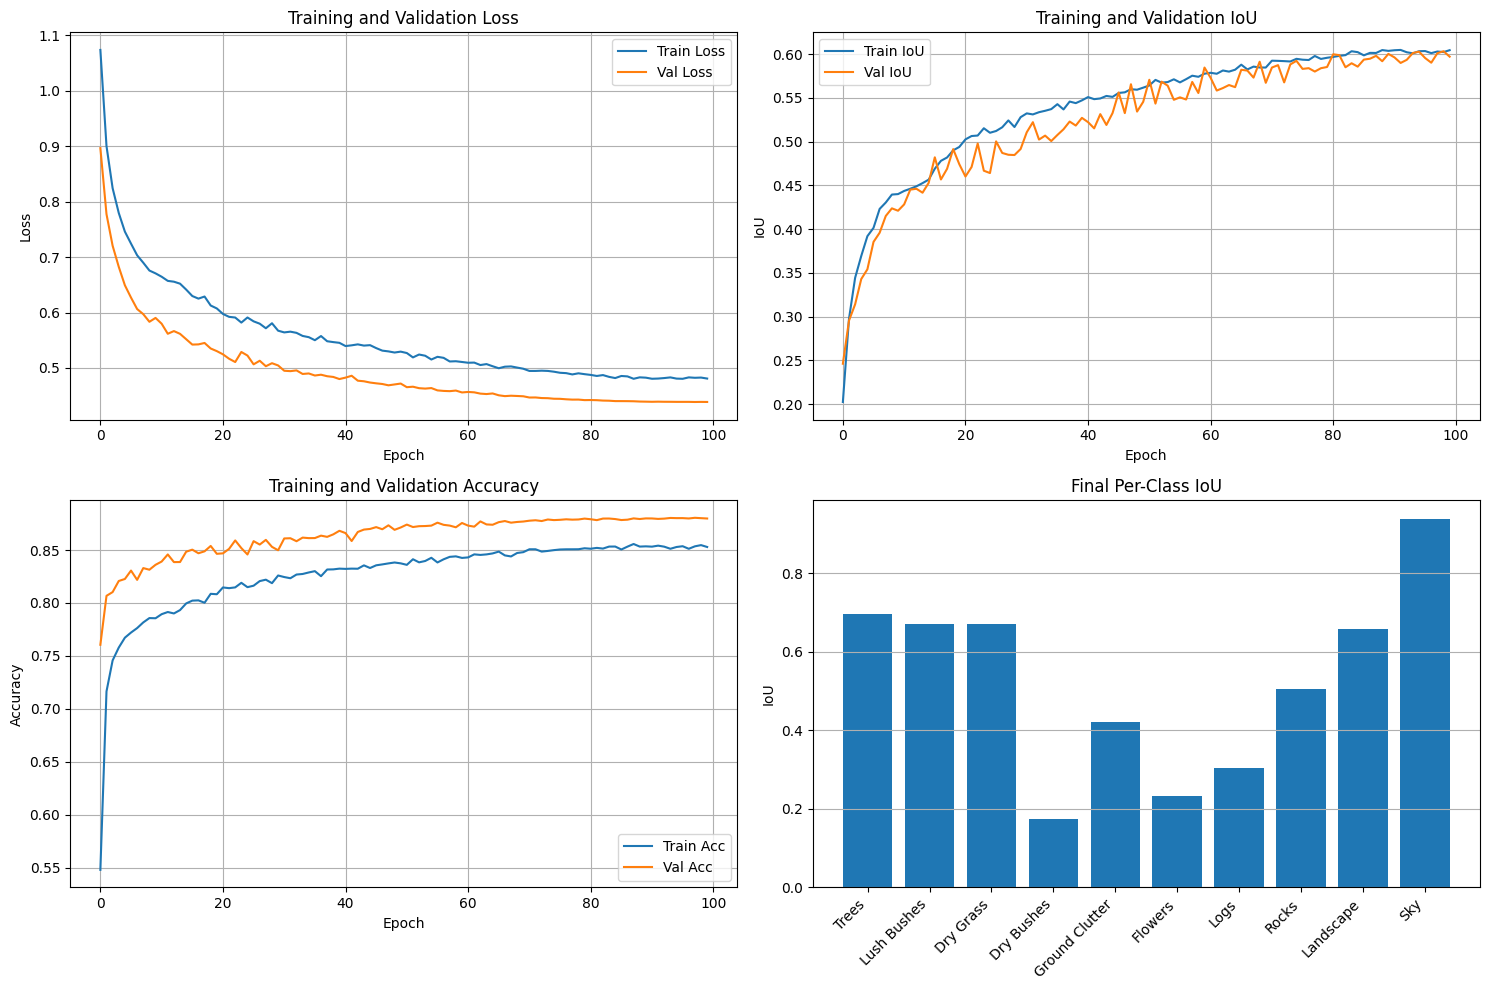

Training curves saved to: /kaggle/working/outputs/unet-resnet34-multi-gpu-20260131-070945/training_curves.png


In [23]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# IoU
axes[0, 1].plot(history['train_iou'], label='Train IoU')
axes[0, 1].plot(history['val_iou'], label='Val IoU')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('IoU')
axes[0, 1].set_title('Training and Validation IoU')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Accuracy
axes[1, 0].plot(history['train_acc'], label='Train Acc')
axes[1, 0].plot(history['val_acc'], label='Val Acc')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Training and Validation Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Per-class IoU (last epoch)
if len(history['class_ious']) > 0:
    last_class_ious = history['class_ious'][-1]
    axes[1, 1].bar(range(len(Config.CLASS_NAMES)), last_class_ious)
    axes[1, 1].set_xticks(range(len(Config.CLASS_NAMES)))
    axes[1, 1].set_xticklabels(Config.CLASS_NAMES, rotation=45, ha='right')
    axes[1, 1].set_ylabel('IoU')
    axes[1, 1].set_title('Final Per-Class IoU')
    axes[1, 1].grid(True, axis='y')

plt.tight_layout()
plt.savefig(Path(Config.OUTPUT_DIR) / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Training curves saved to: {Config.OUTPUT_DIR}/training_curves.png")

In [24]:
# After training completes - create final comprehensive backup

print("\n" + "="*70)
print("CREATING FINAL BACKUP ZIP")
print("="*70)

# Save training history
history_path = Path(Config.OUTPUT_DIR) / "training_history.json"
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"✓ Saved: training_history.json")

# Create final summary
summary_path = Path(Config.OUTPUT_DIR) / "training_summary.txt"
with open(summary_path, 'w') as f:
    f.write(f"Training Summary - {Config.RUN_NAME}\n")
    f.write("=" * 70 + "\n\n")
    f.write(f"Best Val IoU: {best_iou:.4f}\n")
    f.write(f"Best Val Acc: {max(history['val_acc']):.4f}\n")
    f.write(f"Total Epochs: {len(history['val_iou'])}\n")
    f.write(f"Final Epoch: {len(history['val_iou'])}\n\n")
    f.write("Final Per-Class IoU:\n")
    if history['class_ious']:
        for name, iou in zip(Config.CLASS_NAMES, history['class_ious'][-1]):
            f.write(f"  {name:15s}: {iou:.4f}\n")
print(f"✓ Saved: training_summary.txt")

# Create FINAL comprehensive ZIP
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
final_zip = f"/kaggle/working/FINAL_BACKUP_{Config.RUN_NAME}_{timestamp}.zip"

print(f"\nCreating comprehensive final backup...")
with zipfile.ZipFile(final_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # Best model
    best_model_path = Path(Config.CHECKPOINT_DIR) / "best_model.pth"
    if best_model_path.exists():
        zipf.write(best_model_path, arcname="best_model.pth")
        print(f"  ✓ Added: best_model.pth")
    
    # All checkpoints
    for ckpt_file in sorted(Path(Config.CHECKPOINT_DIR).glob("*.pth")):
        zipf.write(ckpt_file, arcname=f"checkpoints/{ckpt_file.name}")
        print(f"  ✓ Added: {ckpt_file.name}")
    
    # Training history
    zipf.write(history_path, arcname="training_history.json")
    print(f"  ✓ Added: training_history.json")
    
    # Summary
    zipf.write(summary_path, arcname="training_summary.txt")
    print(f"  ✓ Added: training_summary.txt")
    
    # All plots and outputs
    for output_file in Path(Config.OUTPUT_DIR).glob("*"):
        if output_file.is_file():
            zipf.write(output_file, arcname=f"outputs/{output_file.name}")
            print(f"  ✓ Added: {output_file.name}")

final_size_mb = Path(final_zip).stat().st_size / (1024 * 1024)

print("\n" + "="*70)
print("🎉 FINAL BACKUP COMPLETE!")
print("="*70)
print(f"📦 File: {Path(final_zip).name}")
print(f"📊 Size: {final_size_mb:.2f} MB")
print(f"📁 Location: /kaggle/working/")
print("\n💾 Download this file from Kaggle Output section")
print("="*70)


CREATING FINAL BACKUP ZIP
✓ Saved: training_history.json
✓ Saved: training_summary.txt

Creating comprehensive final backup...
  ✓ Added: best_model.pth
  ✓ Added: best_model.pth
  ✓ Added: checkpoint_epoch_94.pth
  ✓ Added: checkpoint_epoch_95.pth
  ✓ Added: checkpoint_epoch_99.pth
  ✓ Added: training_history.json
  ✓ Added: training_summary.txt
  ✓ Added: training_summary.txt
  ✓ Added: training_curves.png
  ✓ Added: training_history.json

🎉 FINAL BACKUP COMPLETE!
📦 File: FINAL_BACKUP_unet-resnet34-multi-gpu-20260131-070945_20260131_141423.zip
📊 Size: 1287.52 MB
📁 Location: /kaggle/working/

💾 Download this file from Kaggle Output section


In [26]:
!zip -r training_output.zip outputs

  adding: outputs/ (stored 0%)
  adding: outputs/unet-resnet34-multi-gpu-20260131-070945/ (stored 0%)
  adding: outputs/unet-resnet34-multi-gpu-20260131-070945/training_summary.txt (deflated 49%)
  adding: outputs/unet-resnet34-multi-gpu-20260131-070945/training_curves.png (deflated 11%)
  adding: outputs/unet-resnet34-multi-gpu-20260131-070945/training_history.json (deflated 63%)


In [30]:
from IPython.display import FileLink
FileLink("/kaggle/working/training_output.zip")

/kaggle/working/training_output.zip